## Bước 1 — Cấu hình (chỉ cần sửa ô này)

In [13]:
# ==================== CHI CAN SUA MUC NAY ====================
FOLDER = r'E:\AZIMUTH_TEST_LAN1\VTU0510-20260701T053144Z-3-001\VTU0510'   # <<< THU MUC ANH CAN XU LY

# --- trong so 2 model (mac dinh = model da chot cua khoa luan) ---
POSE = r'E:\AZIMUTH_TEST_LAN1\27072026\training_results_yolo26m\pose_model\weights\best.pt'
DET  = r'E:\AZIMUTH_TEST_LAN1\5_MODEL_MOI\mid_again\runs\detect\telecom_vision_project\yolo26m_telecom\weights\best.pt'

IMGSZ     = 640      # PHAI la 640 (model train o 640)
POSE_CONF = 0.20  # nguong pose; nang len lam mat anten-5G o anh chup xa
DET_CONF  = 0.55     # nguong detect (chi dung de lay NHAN LOP)
IOU_MATCH = 0.30    # nguong IoU khi ghep pose <-> detect

# --- huong chup cua tung anh ---
# Anh ANH_TEST (tram HCM0166, 97/23A Hung Phu Q8, 10,7499N 106,6807E) bi Zalo xoa EXIF,
# nhung GPS Map Camera co IN huong chup vao goc duoi anh -> doc tay tu watermark:
HEADING_MANUAL  = {
    'z7482326311287_64f7b768515d6d6d9db4e819c6924816.jpg':  30.0,   # Hinh 01 - 30 NE
    'z7482326376469_6a1dd8bd8a5aaf74884b4c4882d7b88a.jpg':  90.0,   # Hinh 02 - 90 E
    'z7482326340009_526a5638ff70f0e2d8884c1794795a61.jpg': 150.0,   # Hinh 03 - 150 SE
    'z7482326339933_756450cb5f3537b76a58b46bad30d59d.jpg': 210.0,   # Hinh 04 - 210 SW
    'z7482326376468_d4d41df6daa0dfe0c4f3cdade6ea73c0.jpg': 270.0,   # Hinh 05 - 270 W
    'z7482326325953_491400d7a67a67d52e678a534ba35dce.jpg': 330.0,   # Hinh 06 - 330 NW
}
HEADING_DEFAULT = 0.0      # dung khi khong tim duoc heading

# --- hieu chinh la ban ---
AZIMUTH_OFFSET = 0.0       # 0 = CHUA hieu chinh -> azimuth chi dung TUONG DOI (xem ghi chu cuoi)

OUT_DIR = None             # None -> tao '<FOLDER>/_ketqua_azimuth'
# =============================================================

## Bước 2 — Nạp thư viện và hai model

In [14]:
import os, sys, glob, math, warnings
import numpy as np, pandas as pd, cv2
import matplotlib.pyplot as plt
%matplotlib inline
from PIL import Image, ExifTags
from ultralytics import YOLO

sys.path.insert(0, r'E:\AZIMUTH_TEST_LAN1')                 # de import duoc azimuth_optimized
from azimuth_optimized import (estimate_focal_px, detect_antennas, circ_dist,
                               DIMS_BY_NAME, SKIP_NAMES)

# ---- kiem tra duong dan truoc khi chay, bao loi ro rang thay vi chet giua duong ----
for p, ten in ((FOLDER, 'FOLDER'), (POSE, 'POSE'), (DET, 'DET')):
    if not os.path.exists(p):
        raise FileNotFoundError(f'{ten} khong ton tai: {p}')

FILES = sorted(f for f in glob.glob(os.path.join(FOLDER, '*.*'))
               if f.lower().endswith(('.jpg', '.jpeg', '.png')))
if not FILES:
    raise FileNotFoundError(f'Khong co anh .jpg/.jpeg/.png trong {FOLDER}')

OUT_DIR = OUT_DIR or os.path.join(FOLDER, '_ketqua_azimuth')
os.makedirs(OUT_DIR, exist_ok=True)

if IMGSZ != 640:
    warnings.warn(f'IMGSZ = {IMGSZ} khac 640 -> do chinh xac se tut. Model train o 640.')

pose_model = YOLO(POSE)
det_model  = YOLO(DET)
print(f'Anh trong thu muc : {len(FILES)}')
print(f'Lop cua model det : {list(det_model.names.values())}   (bo qua: {sorted(SKIP_NAMES)})')
print(f'Kich thuoc anten  : ' + ', '.join(f'{k} H:W={v[0]/v[1]:.2f}' for k, v in DIMS_BY_NAME.items()))
print(f'Ket qua se luu vao: {OUT_DIR}')

Anh trong thu muc : 3
Lop cua model det : ['anten-4G', 'anten-5G', 'none', 'rrh', 'rru', 'viba']   (bo qua: ['none'])
Kich thuoc anten  : anten-4G H:W=2.30, anten-5G H:W=1.10, rrh H:W=1.00, rru H:W=1.00, viba H:W=1.00
Ket qua se luu vao: E:\AZIMUTH_TEST_LAN1\VTU0510-20260701T053144Z-3-001\VTU0510\_ketqua_azimuth


In [15]:
import re

def heading_tu_exif(fp):
    # doc GPSImgDirection trong EXIF; khong co -> None
    try:
        ex = Image.open(fp)._getexif() or {}
    except Exception:
        return None
    gps = next((v for k, v in ex.items() if ExifTags.TAGS.get(k) == 'GPSInfo'), None)
    if not gps:
        return None
    g = {ExifTags.GPSTAGS.get(k, k): v for k, v in gps.items()}
    v = g.get('GPSImgDirection')
    return None if v is None else float(v) % 360

def heading_tu_ten(fp):
    # ten tep mang so huong: 90.jpg / hd270.jpg / IMG_180.jpg -> 90/270/180
    stem = os.path.splitext(os.path.basename(fp))[0].replace(',', '.')
    if re.fullmatch(r'\d{1,3}(\.\d+)?', stem):                 # ten tep la chinh con so
        v = float(stem)
        return v % 360 if 0 <= v < 360 else None
    m = re.search(r'(?:hd|heading|az|deg)[_\-]?(\d{1,3})', stem, re.I)   # co tien to ro rang
    if m and 0 <= int(m.group(1)) < 360:
        return float(m.group(1))
    m = re.fullmatch(r'.*?[_\-](\d{1,3})', stem)               # so o cuoi ten, vd IMG_180
    if m and 0 <= int(m.group(1)) < 360:
        return float(m.group(1))
    return None

HEADINGS, rows_hd = {}, []
for fp in FILES:
    nm = os.path.basename(fp)
    h, src = heading_tu_exif(fp), 'EXIF GPSImgDirection'
    if h is None:
        h, src = heading_tu_ten(fp), 'ten tep'
    if h is None and nm in HEADING_MANUAL:
        h, src = float(HEADING_MANUAL[nm]) % 360, 'dien tay'
    if h is None:
        h, src = float(HEADING_DEFAULT) % 360, 'mac dinh'
    HEADINGS[nm] = h
    rows_hd.append(dict(anh=nm, heading=h, nguon=src))

df_hd = pd.DataFrame(rows_hd)
display(df_hd)
n_md = int((df_hd.nguon == 'mac dinh').sum())
if n_md:
    print(f'[CANH BAO] {n_md}/{len(df_hd)} anh khong co huong chup thuc -> dien vao HEADING_MANUAL '
          f'o Buoc 1 roi chay lai, neu can azimuth so voi huong Bac.')

,anh,heading,nguon
0,180.jpg,180.0,ten tep
1,270.jpg,270.0,ten tep
2,90.jpg,90.0,ten tep


## Bước 4 — Chạy pose + detect, tính azimuth từng ăng-ten

In [16]:
def lam_bang(dets):
    # doi list detection -> DataFrame de xuat CSV
    rows = []
    for d in dets:
        r = dict(anh=d['image'], heading=d['heading'], lop=d['name'], co_pose=d['has_pose'],
                 focal_px=round(d['focal_px'], 1), nguon_focal=d['nguon_focal'])
        if d['has_pose']:
            r.update(az_rel=round(d['az_rel'], 1), azimuth=round(d['true_az'], 1),
                     tilt=round(d['tilt'], 1), rms_px=round(d['rms'], 2),
                     nghi_van=('FLIP ' if d.get('flipped') else '') + ('ambig' if d.get('ambiguous') else ''))
        rows.append(r)
    return pd.DataFrame(rows)

ALL_DETS = []                          # giu lai de Buoc 6 ve hinh, KHONG chay model lan 2
for fp in FILES:
    nm = os.path.basename(fp)
    img = cv2.imread(fp)
    if img is None:
        print(f'  [BO QUA] khong doc duoc {nm}'); continue
    h, w = img.shape[:2]
    fpx, fsrc = estimate_focal_px(fp, w, h)                  # tieu cu pixel: EXIF > FOV > f35
    dets, _ = detect_antennas(fp, pose_model, det_model, fpx,
                              pose_conf=POSE_CONF, det_conf=DET_CONF,
                              imgsz=IMGSZ, iou_match=IOU_MATCH, with_mc=False)
    n_pose = 0
    for d in dets:
        d.update(image=nm, heading=HEADINGS[nm], model=0, focal_px=fpx, nguon_focal=fsrc)
        if d['has_pose']:
            n_pose += 1
            d['true_az'] = (d['heading'] - d['az_rel'] + AZIMUTH_OFFSET) % 360
        ALL_DETS.append(d)
    print(f'  {nm[:34]:36} hd={HEADINGS[nm]:5.0f} | {len(dets)} thiet bi -> {n_pose} dinh huong duoc | {fsrc}')

df = lam_bang(ALL_DETS)
csv_path = os.path.join(OUT_DIR, 'azimuth_ketqua.csv')
df.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f'\nTong: {len(df)} thiet bi | {int(df.co_pose.sum())} dinh huong duoc')
print(f'Da luu: {csv_path}')
display(df.head(20))

  180.jpg                              hd=  180 | 3 thiet bi -> 2 dinh huong duoc | EXIF f35=69mm
  270.jpg                              hd=  270 | 5 thiet bi -> 4 dinh huong duoc | EXIF f35=69mm
  90.jpg                               hd=   90 | 3 thiet bi -> 2 dinh huong duoc | EXIF f35=115mm

Tong: 11 thiet bi | 8 dinh huong duoc
Da luu: E:\AZIMUTH_TEST_LAN1\VTU0510-20260701T053144Z-3-001\VTU0510\_ketqua_azimuth\azimuth_ketqua.csv


,anh,heading,lop,co_pose,focal_px,nguon_focal,az_rel,azimuth,tilt,rms_px,nghi_van
0,180.jpg,180.0,anten-5G,True,7666.7,EXIF f35=69mm,5.7,174.3,56.9,0.99,
1,180.jpg,180.0,anten-4G,True,7666.7,EXIF f35=69mm,1.0,179.0,47.5,1.09,
2,180.jpg,180.0,rru,False,7666.7,EXIF f35=69mm,NaN,NaN,NaN,NaN,NaN
3,270.jpg,270.0,anten-4G,True,7666.7,EXIF f35=69mm,64.4,205.6,54.1,0.54,
4,270.jpg,270.0,anten-5G,True,7666.7,EXIF f35=69mm,69.5,200.5,47.0,1.24,ambig
5,270.jpg,270.0,anten-4G,True,7666.7,EXIF f35=69mm,-65.5,335.5,52.4,1.48,FLIP ambig
6,270.jpg,270.0,rru,False,7666.7,EXIF f35=69mm,NaN,NaN,NaN,NaN,NaN
7,270.jpg,270.0,anten-5G,True,7666.7,EXIF f35=69mm,-62.7,332.7,50.7,2.85,FLIP ambig
8,90.jpg,90.0,rru,False,12777.8,EXIF f35=115mm,NaN,NaN,NaN,NaN,NaN
9,90.jpg,90.0,anten-4G,True,12777.8,EXIF f35=115mm,-69.3,159.3,58.9,2.10,


## Bước 5 — Tổng hợp theo ảnh và theo lớp

In [17]:
if df.co_pose.any():
    g = df[df.co_pose].groupby('anh')
    print('--- THEO ANH ---')
    for nm, sub in g:
        s = ', '.join(f"{r.lop} {r.azimuth:.1f}°" for r in sub.sort_values('azimuth').itertuples())
        print(f'  {nm[:32]:34} hd={sub.heading.iloc[0]:5.0f} | {len(sub)} anten | {s}')
    print('\n--- THEO LOP ---')
    display(df[df.co_pose].groupby('lop').agg(so_luong=('azimuth', 'size'),
                                              rms_trung_binh=('rms_px', 'mean'),
                                              tilt_trung_binh=('tilt', 'mean')).round(2))
    kho = df[df.co_pose & (df.rms_px > 4)]
    if len(kho):
        print(f'\n[LUU Y] {len(kho)} thiet bi co RMS > 4 px -> keypoint khop kem, azimuth kem tin cay:')
        display(kho[['anh', 'lop', 'azimuth', 'rms_px', 'nghi_van']])
else:
    print('Khong co thiet bi nao dinh huong duoc. Kiem tra lai: anh co anten khong, POSE_CONF, IOU_MATCH.')

thieu_pose = df[~df.co_pose]
if len(thieu_pose):
    print(f'\n{len(thieu_pose)} thiet bi detect duoc nhung KHONG ghep duoc pose (khong tinh azimuth):')
    display(thieu_pose[['anh', 'lop']])

--- THEO ANH ---
  180.jpg                            hd=  180 | 2 anten | anten-5G 174.3°, anten-4G 179.0°
  270.jpg                            hd=  270 | 4 anten | anten-5G 200.5°, anten-4G 205.6°, anten-5G 332.7°, anten-4G 335.5°
  90.jpg                             hd=   90 | 2 anten | anten-5G 153.4°, anten-4G 159.3°

--- THEO LOP ---


,so_luong,rms_trung_binh,tilt_trung_binh
lop,,,
anten-4G,4,1.30,53.22
anten-5G,4,1.92,31.30



3 thiet bi detect duoc nhung KHONG ghep duoc pose (khong tinh azimuth):


,anh,lop
2,180.jpg,rru
6,270.jpg,rru
8,90.jpg,rru


## Bước 6 — Vẽ hình từng ảnh: ảnh có keypoint + la bàn azimuth

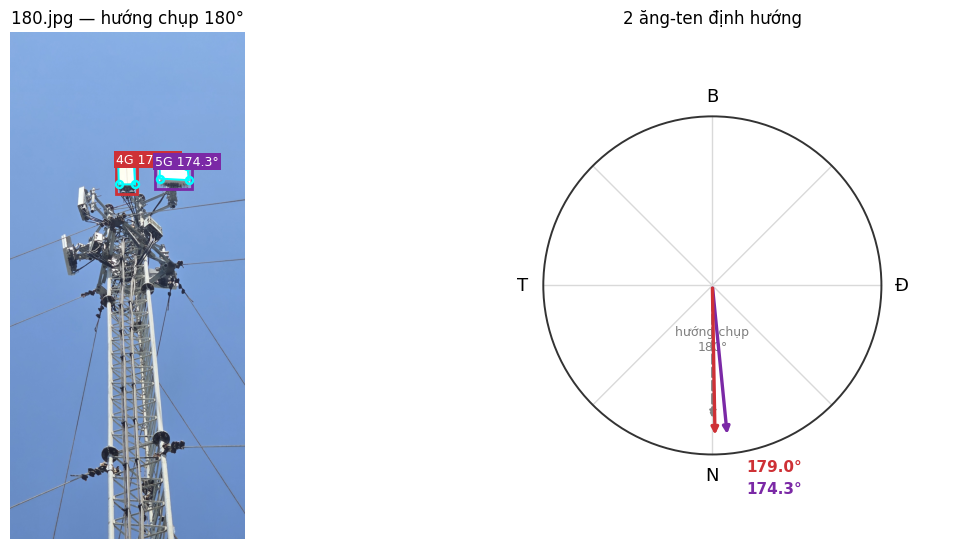

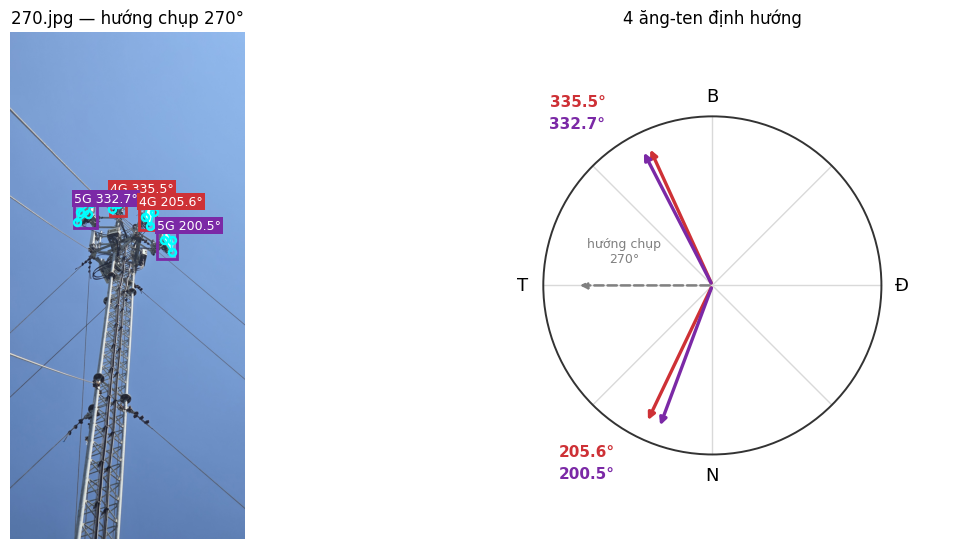

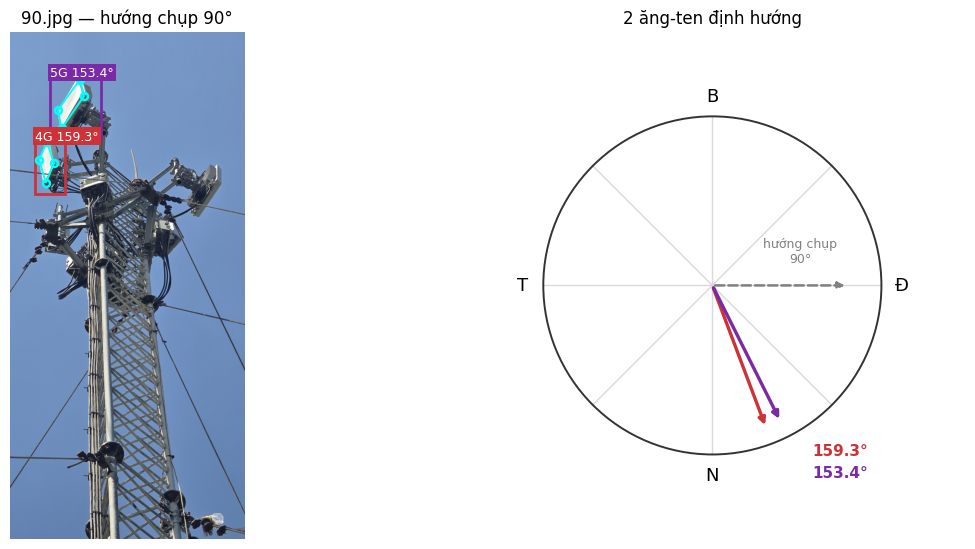

Da luu hinh vao: E:\AZIMUTH_TEST_LAN1\VTU0510-20260701T053144Z-3-001\VTU0510\_ketqua_azimuth


In [18]:
MAU = {'anten-4G': '#CE3136', 'anten-5G': '#7B29A6', 'rrh': '#1B7F3B', 'rru': '#C77B00'}
VE_TIEU_DE = True     # False = bo tieu de trong anh (dung khi dan hinh vao luan van)

def ve_mot_anh(nm, dets, luu=True):
    fp = next(f for f in FILES if os.path.basename(f) == nm)
    rgb = cv2.cvtColor(cv2.imread(fp), cv2.COLOR_BGR2RGB)
    co = [d for d in dets if d.get('has_pose')]
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(13.5, 5.6),
                                 gridspec_kw={'width_ratios': [1.25, 1]})
    a1.imshow(rgb); a1.axis('off')
    cao_nhan = 0.035 * rgb.shape[0]          # chieu cao xap xi cua 1 nhan, theo co anh
    da_dat = []                              # (x1, x2, y) cac nhan da dat -> tranh de chu
    for d in sorted(co, key=lambda z: z['box'][1]):
        c = MAU.get(d['name'], '#333333')
        x1, y1, x2, y2 = d['box']
        a1.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, ec=c, lw=2))
        kp = np.array(d['kp'])
        a1.add_patch(plt.Polygon(kp, fill=False, ec='cyan', lw=1.4))
        a1.plot(kp[:, 0], kp[:, 1], 'o', ms=5, mfc='none', mec='cyan', mew=1.8)
        # day nhan len tung buoc neu cham nhan khac; het cho phia tren thi dat duoi khung
        ty = max(cao_nhan, y1 - 6)
        for _ in range(8):
            if not any(abs(ty - py) < cao_nhan and not (x2 < px1 or x1 > px2)
                       for px1, px2, py in da_dat):
                break
            ty -= cao_nhan
            if ty < cao_nhan:
                ty = y2 + cao_nhan; break
        da_dat.append((x1, x2, ty))
        # nhan ngan (4G/5G thay vi anten-4G) cho bot chen nhau o tram nhieu thiet bi
        a1.text(x1, ty, f"{d['name'].replace('anten-', '')} {d['true_az']:.1f}°", color='white',
                fontsize=9, va='center', bbox=dict(facecolor=c, edgecolor='none', pad=1.5))
    if VE_TIEU_DE:
        a1.set_title(f'{nm} — hướng chụp {HEADINGS[nm]:.0f}°', fontsize=12)

    # ---- la ban ----
    a2.add_patch(plt.Circle((0, 0), 1, fill=False, ec='#333', lw=1.4))
    for ang in (0, 45, 90, 135):
        t = math.radians(ang)
        a2.plot([-math.cos(t), math.cos(t)], [-math.sin(t), math.sin(t)], color='#D9D9D9', lw=1, zorder=0)
    for lbl, (x, y) in {'B': (0, 1.12), 'N': (0, -1.12), 'Đ': (1.12, 0), 'T': (-1.12, 0)}.items():
        a2.text(x, y, lbl, ha='center', va='center', fontsize=13)
    hd = math.radians(HEADINGS[nm])
    a2.annotate('', xy=(0.8 * math.sin(hd), 0.8 * math.cos(hd)), xytext=(0, 0),
                arrowprops=dict(arrowstyle='-|>', color='gray', lw=1.8, ls='--'))
    a2.text(0.52 * math.sin(hd), 0.52 * math.cos(hd) + 0.14, f'hướng chụp\n{HEADINGS[nm]:.0f}°',
            color='gray', fontsize=9, ha='center')
    for d in co:
        t = math.radians(d['true_az'])
        a2.annotate('', xy=(0.9 * math.sin(t), 0.9 * math.cos(t)), xytext=(0, 0),
                    arrowprops=dict(arrowstyle='-|>', color=MAU.get(d['name'], '#333'), lw=2.4))
    # nhan gia tri: gom tia gan nhau thanh cum roi xep doc, tranh de chu khi 2 anten sat huong
    cums = []
    for d in sorted(co, key=lambda z: -z['true_az']):
        for cm in cums:
            if min(circ_dist(d['true_az'], z['true_az']) for z in cm) < 25:
                cm.append(d); break
        else:
            cums.append([d])
    for cm in cums:
        vx = sum(math.sin(math.radians(z['true_az'])) for z in cm) / len(cm)
        vy = sum(math.cos(math.radians(z['true_az'])) for z in cm) / len(cm)
        n = math.hypot(vx, vy) or 1.0
        vx, vy = vx / n, vy / n
        lx, ly = 1.14 * vx, 1.14 * vy
        if abs(vx) < 0.45:                       # tia gan truc doc -> lech ngang de khong de chu B/N
            lx += 0.30 if vx >= 0 else -0.30
        elif abs(vy) < 0.45:                     # tia gan truc ngang -> lech doc de khong de chu D/T
            ly += 0.16 if vy >= 0 else -0.16
        ly += 0.065 * (len(cm) - 1)              # can giua cum nhan
        for k, z in enumerate(cm):
            a2.text(lx, ly - 0.13 * k, f"{z['true_az']:.1f}°", color=MAU.get(z['name'], '#333'),
                    fontsize=11, fontweight='bold', ha='center', va='center')
    a2.set_xlim(-1.5, 1.5); a2.set_ylim(-1.5, 1.5); a2.set_aspect('equal'); a2.axis('off')
    if VE_TIEU_DE:
        a2.set_title(f'{len(co)} ăng-ten định hướng', fontsize=12)
    plt.tight_layout()
    if luu:
        out = os.path.join(OUT_DIR, f'azimuth_{os.path.splitext(nm)[0]}.png')
        fig.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()

theo_anh = {}
for d in ALL_DETS:
    theo_anh.setdefault(d['image'], []).append(d)
for nm in sorted(theo_anh):
    ve_mot_anh(nm, theo_anh[nm])
print(f'Da luu hinh vao: {OUT_DIR}')